# Práctica 2 — Análisis Exploratorio de Datos con Python
**Universidad de San Carlos de Guatemala — ECFM**  
**Programación 1**

Dataset: [Stars Dataset](https://www.kaggle.com/datasets/waqi786/stars-dataset) — 1 000 estrellas con 28 clases espectrales distintas.

---

## Sección 1 — Configuración del ambiente y carga de datos

### 1.1 · Importar librerías

Documentación:
- NumPy → https://numpy.org/doc/stable/
- Pandas → https://pandas.pydata.org/docs/
- Matplotlib → https://matplotlib.org/stable/api/pyplot_summary.html
- Seaborn → https://seaborn.pydata.org/api.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración opcional: mejora la apariencia de las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print(" Librerías importadas correctamente")
print(f"   numpy   {np.__version__}")
print(f"   pandas  {pd.__version__}")

 Librerías importadas correctamente
   numpy   2.0.2
   pandas  2.2.2


### 1.2 · Cargar el dataset



In [6]:
from google.colab import files
uploaded = files.upload()  # te abre un selector de archivos

import io
stars = pd.read_csv(io.BytesIO(uploaded['star_dataset.csv']))
print(f" Dataset cargado: {len(stars)} filas, {stars.columns.tolist()}")

Saving star_dataset.csv to star_dataset.csv
 Dataset cargado: 1000 filas, ['Name', 'Distance (ly)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Temperature (K)', 'Spectral Class']


### 1.3 · Mostrar las primeras filas

In [7]:
stars.head()

,Name,Distance (ly),Luminosity (L/Lo),Radius (R/Ro),Temperature (K),Spectral Class
0,Altair,16.594171,9.979192,1.632650,7509.294247,A7V
1,Deneb,2600.490723,196002.627856,202.970526,8503.284796,A2Ia
2,Barnard's Star,6.052616,4.893716,0.222711,3165.959639,M4Ve
3,Polaris,322.601002,2196.241934,37.546813,6048.326915,F7Ib
4,Barnard's Star,5.902392,-1.496486,0.192359,3130.602069,M4Ve


### 1.4 · Verificar dimensiones  y tipos de datos

In [8]:
print("Dimensiones del dataset (filas, columnas):")
print(stars.shape)

print("\nTipos de datos de cada columna:")
print(stars.dtypes)

Dimensiones del dataset (filas, columnas):
(1000, 6)

Tipos de datos de cada columna:
Name                  object
Distance (ly)        float64
Luminosity (L/Lo)    float64
Radius (R/Ro)        float64
Temperature (K)      float64
Spectral Class        object
dtype: object


---
## Sección 2 — Exploración estadística y comparación de técnicas

### 2.1 · Estadísticas descriptivas

In [9]:
stars.describe()

,Distance (ly),Luminosity (L/Lo),Radius (R/Ro),Temperature (K)
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,295.505327,19644.909442,86.960696,9983.486779
std,541.478403,42223.595017,213.850005,7906.973529
min,3.877798,-4.993141,0.068087,2750.183163
25%,11.716853,10.441039,1.664479,3940.020856
50%,52.031435,171.097809,5.845444,7379.007975
75%,322.865874,10500.577117,33.719778,12055.975095
max,2600.490723,196004.854081,887.097936,28044.279272


### 2.2 · Verificar valores nulos

In [10]:
print("Valores nulos por columna:")
nulos = stars.isnull().sum()
print(nulos)

print(f"\nTotal de valores nulos: {nulos.sum()}")

Valores nulos por columna:
Name                 0
Distance (ly)        0
Luminosity (L/Lo)    0
Radius (R/Ro)        0
Temperature (K)      0
Spectral Class       0
dtype: int64

Total de valores nulos: 0


### 2.3 · Contar estrellas por clase espectral

In [11]:
conteo_clases = stars["Spectral Class"].value_counts()
print("Cantidad de estrellas por clase espectral:")
print(conteo_clases)

Cantidad de estrellas por clase espectral:
Spectral Class
A7V         74
A1V         73
A9II        48
B1III       45
M3.5V       45
M2Iab       44
G8III       39
M4Ve        38
K1.5III     38
A0V         38
M7IIIe      37
B2III       37
B0Ia        36
G2V         36
F7Ib        35
B1III-IV    32
A3V         31
F5IV-V      30
B0.5IV      30
B6Vep       29
M2.1V       27
B7V         26
M1.5Iab     26
A2Ia        25
K1V         24
M6V         22
K5III       18
B8Ia        17
Name: count, dtype: int64


### 2.4 · Temperatura media de la clase A7V

In [12]:
# Paso 1: Filtrar el DataFrame para la clase espectral A7V
clase_objetivo = "A7V"
estrellas_a7v = stars[stars["Spectral Class"] == clase_objetivo]

# Paso 2: Recorrer la columna con un ciclo for, acumulando suma y conteo
suma_temp = 0
conteo_temp = 0

for temperatura in estrellas_a7v["Temperature (K)"]:
    suma_temp += temperatura
    conteo_temp += 1

# Paso 3: Calcular la media
if conteo_temp > 0:
    media_a7v_for = suma_temp / conteo_temp
    print(f"Clase espectral: {clase_objetivo}")
    print(f"Número de estrellas: {conteo_temp}")
    print(f"Temperatura media (ciclo for): {media_a7v_for:.2f} K")
else:
    print(f"No se encontraron estrellas de clase {clase_objetivo}")

Clase espectral: A7V
Número de estrellas: 74
Temperatura media (ciclo for): 7550.18 K


### 2.5 · Temperatura promedio para TODAS las clases

In [13]:
# Una sola línea reemplaza el ciclo for para TODAS las clases a la vez
temp_por_clase = stars.groupby("Spectral Class")["Temperature (K)"].mean()

print("Temperatura promedio por clase espectral (pandas groupby):")
print(temp_por_clase.sort_values(ascending=False))

# Comparación con el resultado del ciclo for
media_a7v_pandas = temp_por_clase.get(clase_objetivo, None)
print(f"\n--- Comparación para clase {clase_objetivo} ---")
print(f"Ciclo for : {media_a7v_for:.4f} K")
print(f"groupby   : {media_a7v_pandas:.4f} K")
print(f"Diferencia: {abs(media_a7v_for - media_a7v_pandas):.6f} K  ← prácticamente cero")

Temperatura promedio por clase espectral (pandas groupby):
Spectral Class
B0.5IV      28001.166630
B0Ia        27502.303666
B1III-IV    25403.170510
B1III       25001.131122
B2III       22600.139741
B6Vep       15003.610593
B7V         12462.119029
B8Ia        12092.293145
A1V         10136.022204
A0V          9607.458129
A3V          8584.693288
A2Ia         8516.840653
A7V          7550.178313
A9II         7349.223744
F5IV-V       6520.419327
F7Ib         6020.393400
G2V          5797.996506
K1V          5261.645715
G8III        4939.733287
K1.5III      4280.090548
K5III        3923.614977
M2Iab        3502.196868
M1.5Iab      3499.130207
M2.1V        3408.914115
M4Ve         3136.076002
M7IIIe       2914.515688
M3.5V        2802.627176
M6V          2795.196060
Name: Temperature (K), dtype: float64

--- Comparación para clase A7V ---
Ciclo for : 7550.1783 K
groupby   : 7550.1783 K
Diferencia: 0.000000 K  ← prácticamente cero


### 2.6 · Estadísticas NumPy de la temperatura: media, mediana, desviación estándar

In [14]:
temperaturas = stars["Temperature (K)"].values  # array NumPy

media_np   = np.mean(temperaturas)
mediana_np = np.median(temperaturas)
std_np     = np.std(temperaturas)

print("Estadísticas NumPy — Temperatura (K)")
print(f"  Media             : {media_np:,.2f} K")
print(f"  Mediana           : {mediana_np:,.2f} K")
print(f"  Desviación estándar: {std_np:,.2f} K")

Estadísticas NumPy — Temperatura (K)
  Media             : 9,983.49 K
  Mediana           : 7,379.01 K
  Desviación estándar: 7,903.02 K


### 2.7 · Percentiles del radio estelar

In [15]:
radios = stars["Radius (R/Ro)"].values  # array NumPy

p25, p50, p75, p90 = np.percentile(radios, [25, 50, 75, 90])

print("Percentiles del radio estelar (R/R☉):")
print(f"  P25 (primer cuartil) : {p25:.4f}")
print(f"  P50 (mediana)        : {p50:.4f}")
print(f"  P75 (tercer cuartil) : {p75:.4f}")
print(f"  P90                  : {p90:.4f}")

Percentiles del radio estelar (R/R☉):
  P25 (primer cuartil) : 1.6645
  P50 (mediana)        : 5.8454
  P75 (tercer cuartil) : 33.7198
  P90                  : 369.9267


---
## Sección 3 — Visualizaciones

### 3.1 · Gráfica de barras — cantidad de estrellas por clase espectral

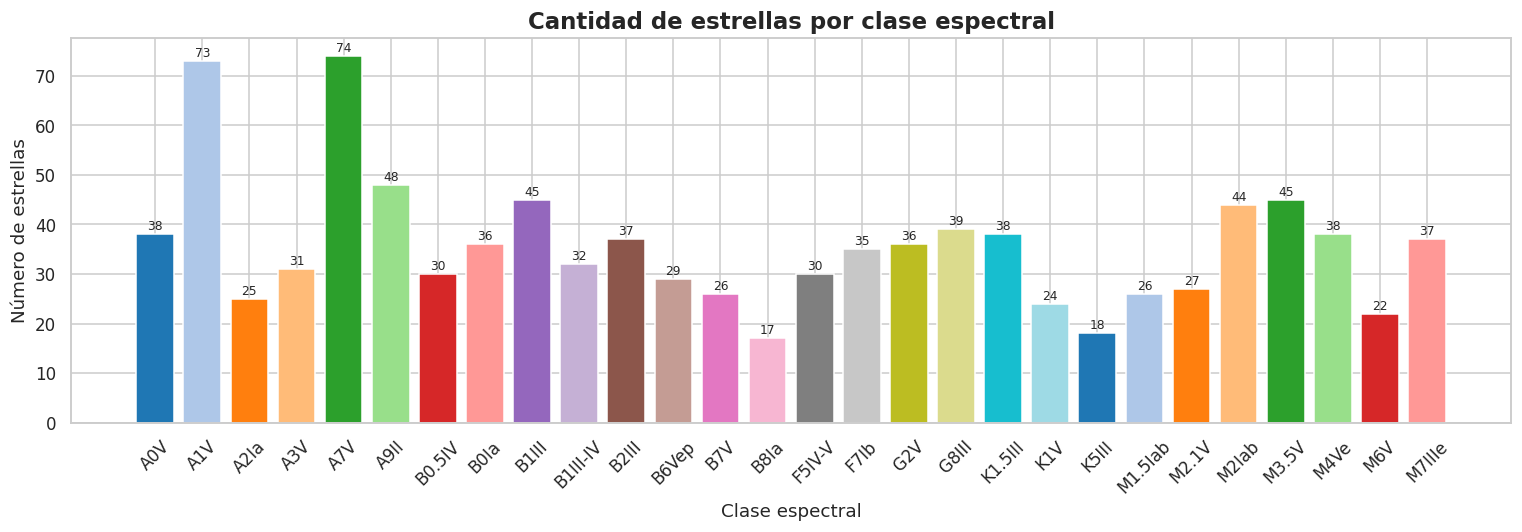

In [16]:
conteo = stars["Spectral Class"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(conteo.index, conteo.values, color=sns.color_palette("tab20", len(conteo)))

ax.set_title("Cantidad de estrellas por clase espectral", fontsize=15, fontweight="bold")
ax.set_xlabel("Clase espectral", fontsize=12)
ax.set_ylabel("Número de estrellas", fontsize=12)
ax.tick_params(axis="x", rotation=45)

# Etiquetas encima de cada barra
for i, (clase, n) in enumerate(zip(conteo.index, conteo.values)):
    ax.text(i, n + 0.3, str(n), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

### 3.2 · Boxplot — distribución de temperatura por clase espectral

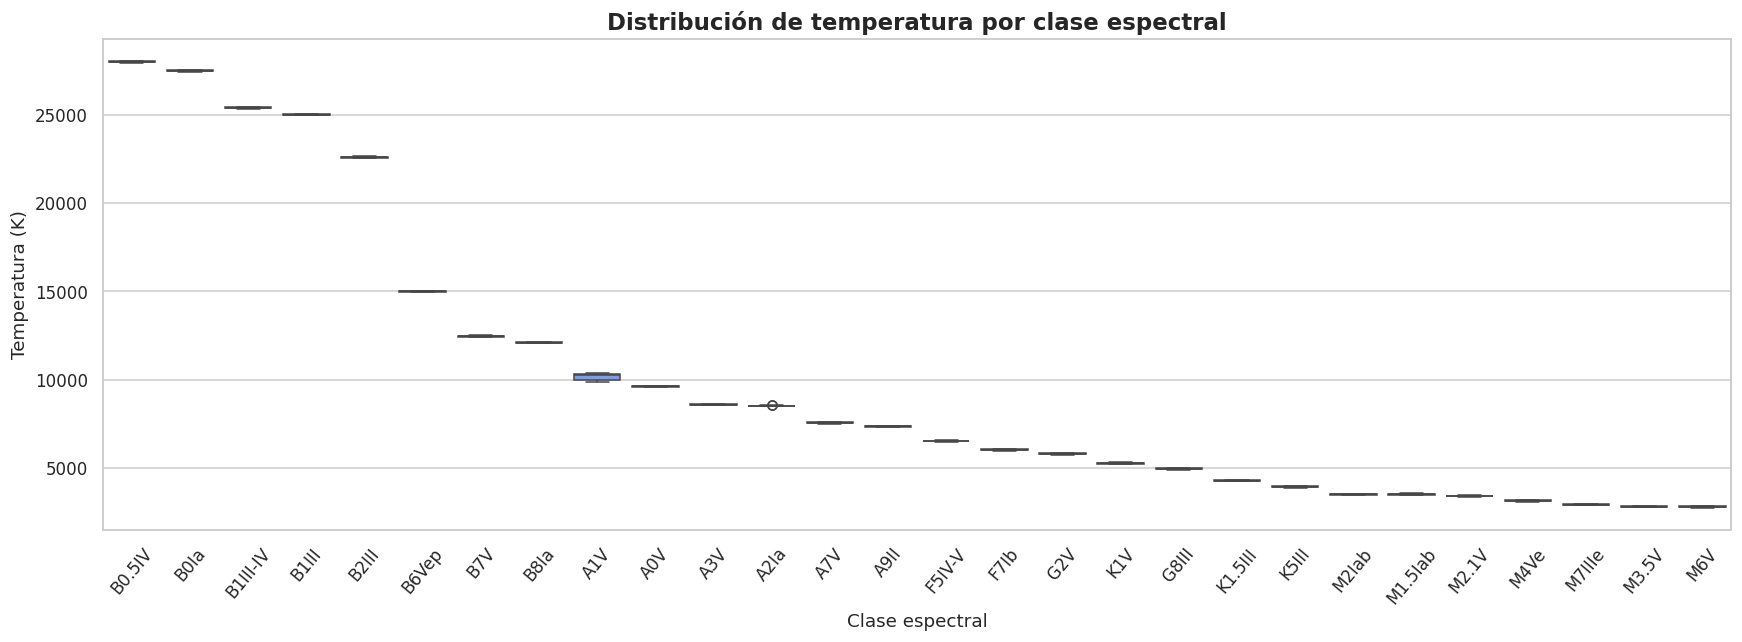

In [24]:
# Ordenar clases por mediana de temperatura (mayor a menor)
orden = (
    stars.groupby("Spectral Class")["Temperature (K)"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(16, 6))

sns.boxplot(
    data=stars,
    x="Spectral Class",
    y="Temperature (K)",
    order=orden,
    hue="Spectral Class",  # ← agregar esto
    legend=False,           # ← y esto
    palette="coolwarm",
    ax=ax
)

ax.set_title("Distribución de temperatura por clase espectral", fontsize=15, fontweight="bold")
ax.set_xlabel("Clase espectral", fontsize=12)
ax.set_ylabel("Temperatura (K)", fontsize=12)
ax.tick_params(axis="x", rotation=50)

plt.tight_layout()
plt.show()

### 3.3 · Scatter plot — Temperatura vs. Luminosidad

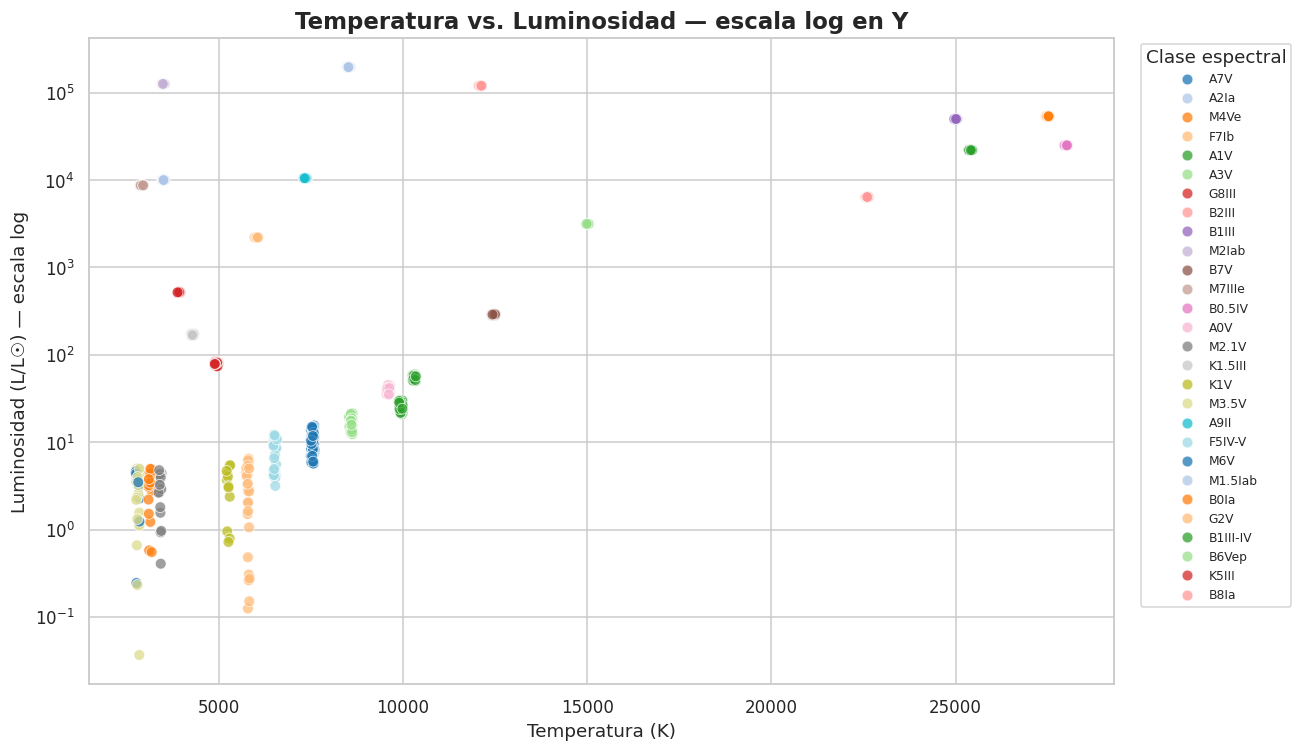

In [18]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=stars,
    x="Temperature (K)",
    y="Luminosity (L/Lo)",
    hue="Spectral Class",
    palette="tab20",
    alpha=0.75,
    s=50,
    ax=ax
)

ax.set_yscale("log")  # Escala logarítmica en el eje Y

ax.set_title("Temperatura vs. Luminosidad — escala log en Y", fontsize=15, fontweight="bold")
ax.set_xlabel("Temperatura (K)", fontsize=12)
ax.set_ylabel("Luminosidad (L/L☉) — escala log", fontsize=12)
ax.legend(title="Clase espectral", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

### 3.4 · Diagrama de Hertzsprung-Russell

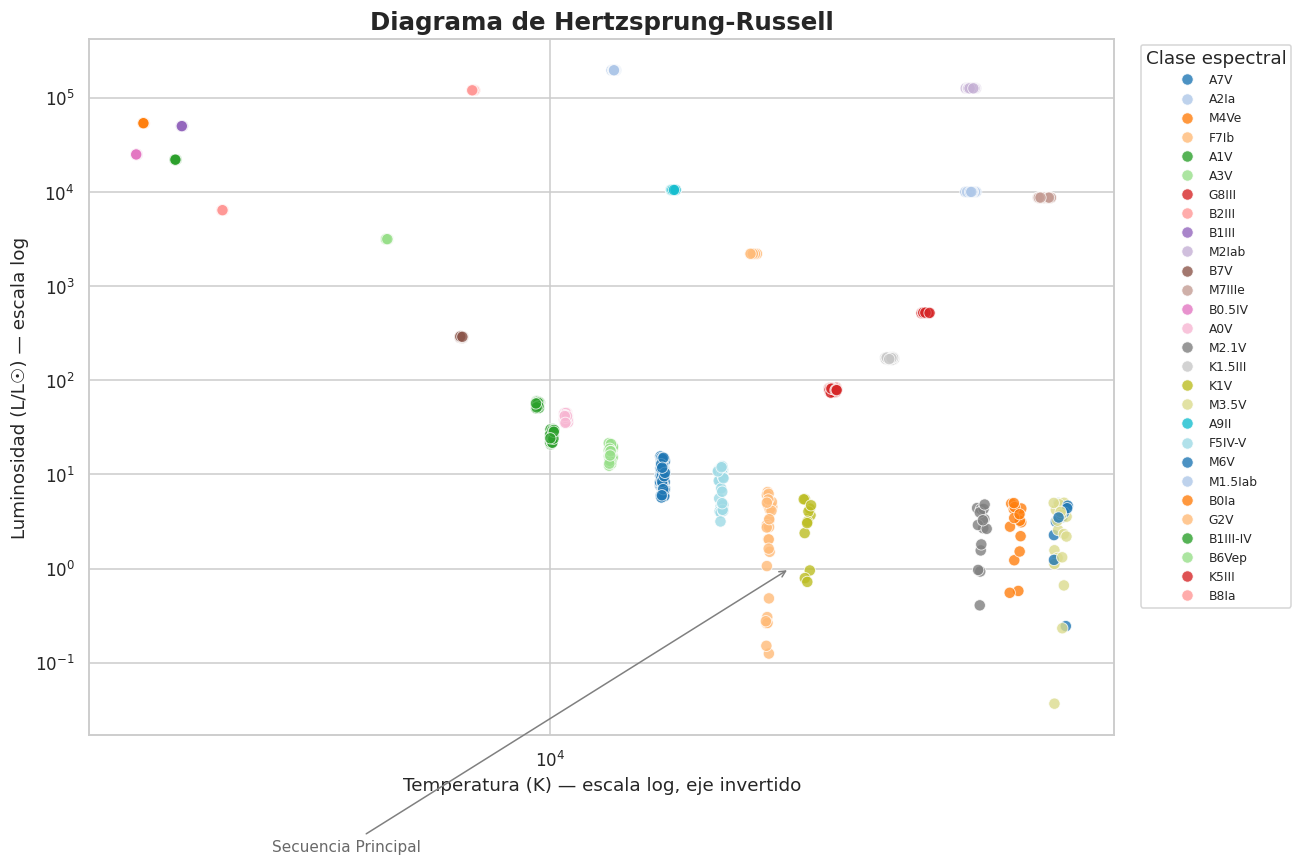

In [19]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=stars,
    x="Temperature (K)",
    y="Luminosity (L/Lo)",
    hue="Spectral Class",
    palette="tab20",
    alpha=0.80,
    s=55,
    ax=ax
)

# Ambos ejes en escala logarítmica
ax.set_xscale("log")
ax.set_yscale("log")

# Invertir el eje X: estrellas más calientes (mayor T) a la izquierda
ax.invert_xaxis()

ax.set_title("Diagrama de Hertzsprung-Russell", fontsize=16, fontweight="bold")
ax.set_xlabel("Temperatura (K) — escala log, eje invertido", fontsize=12)
ax.set_ylabel("Luminosidad (L/L☉) — escala log", fontsize=12)
ax.legend(title="Clase espectral", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

# Anotaciones de las regiones principales del diagrama H-R
ax.annotate(
    "Secuencia Principal",
    xy=(5500, 1), xytext=(20000, 0.001),
    arrowprops=dict(arrowstyle="->", color="gray"),
    fontsize=10, color="dimgray"
)

plt.tight_layout()
plt.show()

---
## Sección 4 — Estadísticas vectorizadas

### 4.1 · Extraer columna de temperaturas

In [20]:
# Extraer la columna como array NumPy
temperaturas_np = stars["Temperature (K)"].values

print(f"Tipo del objeto: {type(temperaturas_np)}")
print(f"Forma (shape)  : {temperaturas_np.shape}")
print(f"Tipo de dato   : {temperaturas_np.dtype}")
print(f"Primeros 5 valores: {temperaturas_np[:5]}")

Tipo del objeto: <class 'numpy.ndarray'>
Forma (shape)  : (1000,)
Tipo de dato   : float64
Primeros 5 valores: [7509.29424736 8503.28479643 3165.95963924 6048.32691476 3130.60206924]


### 4.2 · Media, mediana y desviación estándar de la temperatura

In [21]:
media_d    = np.mean(temperaturas_np)
mediana_d  = np.median(temperaturas_np)
std_d      = np.std(temperaturas_np)

print("Estadísticas NumPy — Temperatura (K)")
print(f"  Media              : {media_d:>12,.2f} K")
print(f"  Mediana            : {mediana_d:>12,.2f} K")
print(f"  Desviación estándar: {std_d:>12,.2f} K")

Estadísticas NumPy — Temperatura (K)
  Media              :     9,983.49 K
  Mediana            :     7,379.01 K
  Desviación estándar:     7,903.02 K


### 4.3 · Percentiles 25, 50, 75 y 90 del radio estelar

In [22]:
radios_np = stars["Radius (R/Ro)"].values

percentiles = np.percentile(radios_np, [25, 50, 75, 90])

print("Percentiles del radio estelar (R/R☉):")
for p, val in zip([25, 50, 75, 90], percentiles):
    print(f"  Percentil {p:>2}°: {val:.4f} R☉")

Percentiles del radio estelar (R/R☉):
  Percentil 25°: 1.6645 R☉
  Percentil 50°: 5.8454 R☉
  Percentil 75°: 33.7198 R☉
  Percentil 90°: 369.9267 R☉


### 4.4 · Conversión vectorizada de temperatura: Kelvin → Celsius



In [23]:
# Conversión vectorizada: sin ciclos for
celsius = temperaturas_np - 273.15

print("Conversión Kelvin → Celsius (primeros 10 valores):")
print(f"{'Kelvin':>12}  {'Celsius':>12}")
print("-" * 27)
for k, c in zip(temperaturas_np[:10], celsius[:10]):
    print(f"{k:>12.2f}  {c:>12.2f}")

print(f"\nEstadísticas de temperatura en Celsius:")
print(f"  Mínima : {celsius.min():>10.2f} °C")
print(f"  Máxima : {celsius.max():>10.2f} °C")
print(f"  Media  : {celsius.mean():>10.2f} °C")

Conversión Kelvin → Celsius (primeros 10 valores):
      Kelvin       Celsius
---------------------------
     7509.29       7236.14
     8503.28       8230.13
     3165.96       2892.81
     6048.33       5775.18
     3130.60       2857.45
     9903.97       9630.82
     8541.20       8268.05
     4979.49       4706.34
     4907.78       4634.63
    22573.29      22300.14

Estadísticas de temperatura en Celsius:
  Mínima :    2477.03 °C
  Máxima :   27771.13 °C
  Media  :    9710.34 °C


---
## Resumen de resultados

| Medida | Valor |
|--------|-------|
| Total de estrellas | 1 000 |
| Clases espectrales distintas | 28 |
| Temperatura media (K) | ver celda 4.2 |
| Temperatura mediana (K) | ver celda 4.2 |
| Temperatura desv. estándar (K) | ver celda 4.2 |

**Conclusión sobre ciclo `for` vs. `groupby`:**  
Ambos enfoques producen el mismo resultado numérico. El ciclo `for` es didáctico y permite entender  
el algoritmo paso a paso; `groupby().mean()` es la herramienta de producción: más concisa,  
más rápida y menos propensa a errores.

**Conclusión sobre el Diagrama H-R:**  
El diagrama revela la **secuencia principal** (banda diagonal de estrellas), así como grupos  
de gigantes y supergigantes (alta luminosidad) y enanas (baja luminosidad). La escala logarítmica  
es imprescindible dado el rango de 12 órdenes de magnitud en la luminosidad.